In [1]:
import numpy as np
import pandas as pd
import pyxdf
import mne
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
XDF_ROOT = Path(r"C:\Users\jshin\OW_closedloopLIFU\xdf_data")
PARTICIPANTS = ["dave", "scott"]
RUNS = [1, 2, 3, 4]
CH_NAMES = ["FCz", "CP3", "P5", "Cz", "Pz", "POz", "CP4"]

def xdf_path_for(participant, run):
    folder = f"sub-{participant}_run_{run}"
    fname = f"sub-{participant}_run_{run}_ses-1_task-{participant}_run_{run}_run-001_eeg.xdf"
    return XDF_ROOT / folder / "ses-1" / "eeg" / fname

In [3]:
DATA_COLS = ["Ch0", "Ch1", "Ch2", "Ch3", "Ch4", "Ch5", "Ch6"]  # maps 1:1 to CH_NAMES

def build_epochs_for_run(xdf_path, tmin=-0.2, tmax=0.8, sfreq=250):
    """Load one XDF recording and return epochs locked to the trial markers, plus the fitted ICA."""
    data, _ = pyxdf.load_xdf(str(xdf_path))
    # Streams aren't always in the same order across recordings, so look them up by name.
    streams = {s['info']['name'][0]: s for s in data}

    # --- EEG stream ---
    eeg_stream = streams['EEG_gpype']
    eeg_df = pd.DataFrame(eeg_stream['time_series'])
    eeg_df = eeg_df.rename(columns={i: f"Ch{i}" for i in range(eeg_df.shape[1])})
    eeg_df['Timestamp'] = eeg_stream['time_stamps']
    eeg_raw = eeg_df[DATA_COLS + ['Timestamp']]

    # --- Trial marker stream ---
    trial_stream = streams['PsychoPyMarkers']
    trial_df = pd.DataFrame(trial_stream['time_series']).rename(columns={0: 'markers'})
    trial_df['Timestamp'] = trial_stream['time_stamps']
    trial_ts = np.asarray(trial_df['Timestamp'])

    # --- Match trial timestamps (LSL clock) to nearest EEG sample index ---
    timestamps = eeg_raw['Timestamp'].values
    insert_idx = np.clip(np.searchsorted(timestamps, trial_ts), 1, len(timestamps) - 1)
    left_vals = timestamps[insert_idx - 1]
    right_vals = timestamps[insert_idx]
    use_left = np.abs(trial_ts - left_vals) < np.abs(trial_ts - right_vals)
    trials = np.where(use_left, insert_idx - 1, insert_idx)

    matched_time = timestamps[trials]
    time_diff = matched_time - trial_ts
    fs = 1 / np.median(np.diff(timestamps))
    expected_max_diff = 0.5 / fs
    n_bad = np.sum(np.abs(time_diff) > expected_max_diff)
    if n_bad > 0:
        print(f"  Warning: {n_bad} of {len(trial_ts)} matches exceed half a sample period "
              f"({expected_max_diff * 1000:.2f} ms).")

    # --- Clean EEG data ---
    df = eeg_raw[DATA_COLS].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.replace(-200000.0, np.nan)

    # Channels that are mostly missing/flatlined (e.g. a disconnected
    # electrode for one run) can't be fixed with a short point-by-point
    # interpolation, so mark them as bad and let MNE reconstruct them
    # spatially from the other channels below. This keeps every run on the
    # same 7-channel layout so they can be concatenated across runs.
    bad_frac = df.isna().mean()
    bad_channels = list(bad_frac[bad_frac > 0.5].index)
    if bad_channels:
        print(f"  Bad channel(s) detected: {bad_channels} -> will interpolate from neighbors")

    df = df.interpolate(method='linear', limit=5, limit_direction='both')
    df = df.bfill().ffill()
    df = df[DATA_COLS]

    # --- Build MNE Raw ---
    info = mne.create_info(ch_names=CH_NAMES, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(df.values.T, info, verbose=False)
    raw.set_montage(mne.channels.make_standard_montage("standard_1020"))
    raw.info['bads'] = [CH_NAMES[DATA_COLS.index(c)] for c in bad_channels]
    if raw.info['bads']:
        raw.interpolate_bads(reset_bads=True, verbose=False)
    raw.filter(1., 40., fir_design='firwin', verbose=False)
    raw.notch_filter(60., verbose=False)
    raw.set_eeg_reference('average', verbose=False)

    # Fit ICA for later inspection, but don't auto-exclude components: the
    # excluded indices depend on visually reviewing each run's decomposition,
    # so there's no single set of indices that generalizes across runs/participants.
    ica = mne.preprocessing.ICA(n_components=0.99999, random_state=97, max_iter='auto', verbose=False)
    ica.fit(raw, verbose=False)

    # --- Epoch around trial markers ---
    events = np.column_stack([trials, np.zeros_like(trials, dtype=int), np.ones_like(trials, dtype=int)])
    epochs = mne.Epochs(raw, events, event_id=1, tmin=tmin, tmax=tmax,
                         baseline=(-0.2, 0), preload=True, verbose=False)
    return epochs, ica

In [4]:
participant_erps = {}
participant_icas = {}

for participant in PARTICIPANTS:
    run_epochs = []
    run_icas = []
    for run in RUNS:
        path = xdf_path_for(participant, run)
        print(f"Loading {participant} run {run}: {path.name}")
        epochs, ica = build_epochs_for_run(path)
        run_epochs.append(epochs)
        run_icas.append(ica)

    all_epochs = mne.concatenate_epochs(run_epochs, on_mismatch='warn')
    participant_erps[participant] = all_epochs.average()
    participant_icas[participant] = run_icas
    print(f"{participant}: {len(all_epochs)} epochs combined across {len(RUNS)} runs\n")

Loading dave run 1: sub-dave_run_1_ses-1_task-dave_run_1_run-001_eeg.xdf


Loading dave run 2: sub-dave_run_2_ses-1_task-dave_run_2_run-001_eeg.xdf


Loading dave run 3: sub-dave_run_3_ses-1_task-dave_run_3_run-001_eeg.xdf


  Bad channel(s) detected: ['Ch0'] -> will interpolate from neighbors


C:\Users\jshin\AppData\Local\Temp\ipykernel_24980\4075491564.py:64: RuntimeWarning: Only 7 head digitization points of the specified kinds ("eeg", "extra",), fitting may be inaccurate
  raw.interpolate_bads(reset_bads=True, verbose=False)


...

Loading scott run 4: sub-scott_run_4_ses-1_task-scott_run_4_run-001_eeg.xdf


Not setting metadata


365 matching events found


Applying baseline correction (mode: mean)


scott: 365 epochs combined across 4 runs



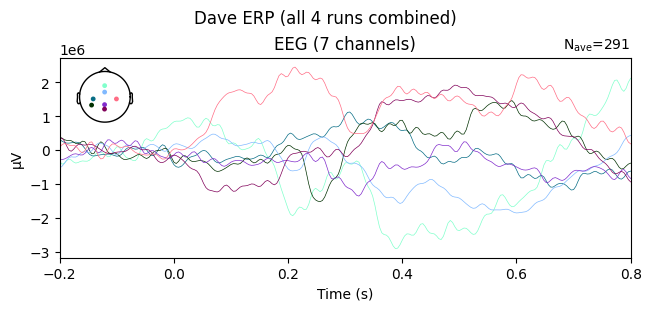

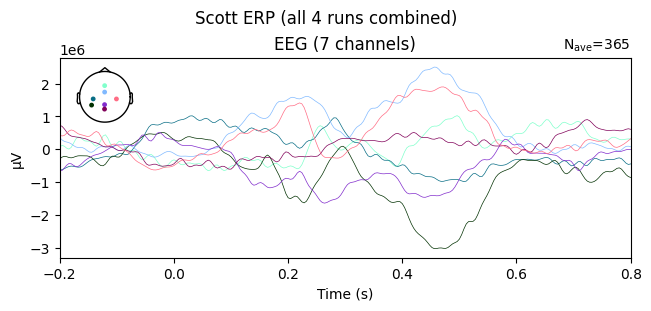

In [5]:
for participant, erp in participant_erps.items():
    fig = erp.plot(show=False)
    fig.suptitle(f"{participant.capitalize()} ERP (all {len(RUNS)} runs combined)")
    plt.show()